In [302]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [303]:
df = pd.read_csv('train.txt',sep=';',header=None,names=['text','emotion'])

In [304]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [305]:
df.isnull().sum()

,0
text,0
emotion,0


In [306]:
unique_emotions = df['emotion'].unique()
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fit and transform the emotion column
df['emotion'] = le.fit_transform(df['emotion'])

# See the mapping clearly
print("Label Mapping:")
for index, label in enumerate(le.classes_):
    print(f"  {label}  →  {index}")

# To decode a prediction back to emotion name later:
# le.inverse_transform([0, 1, 2])  ← gives you emotion names back

Label Mapping:
  anger  →  0
  fear  →  1
  joy  →  2
  love  →  3
  sadness  →  4
  surprise  →  5


In [307]:
df

,text,emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0
...,...,...
15995,i just had a very brief time in the beanbag an...,4
15996,i am now turning and i feel pathetic that i am...,4
15997,i feel strong and good overall,2
15998,i feel like this was such a rude comment and i...,0


##EDA (Exploratory Data Analysis)


In [308]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (16000, 2)

First 5 Rows:


,text,emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0


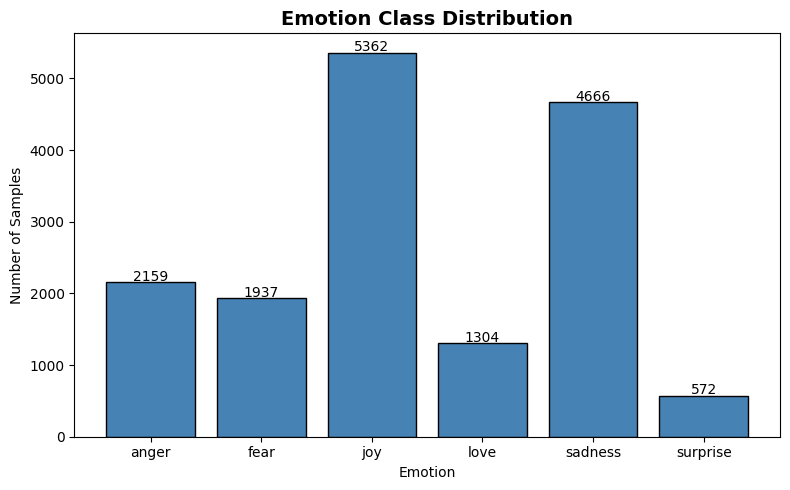


Class Counts:
  anger: 2159
  fear: 1937
  joy: 5362
  love: 1304
  sadness: 4666
  surprise: 572


In [309]:
# --- Emotion Class Distribution ---
emotion_names = le.classes_   # ['anger', 'fear', 'joy', ...] etc.
emotion_counts = df['emotion'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(emotion_names, emotion_counts.values, color='steelblue', edgecolor='black')
plt.title('Emotion Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')

# Show count on top of each bar
for bar, count in zip(bars, emotion_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nClass Counts:")
for name, count in zip(emotion_names, emotion_counts.values):
    print(f"  {name}: {count}")

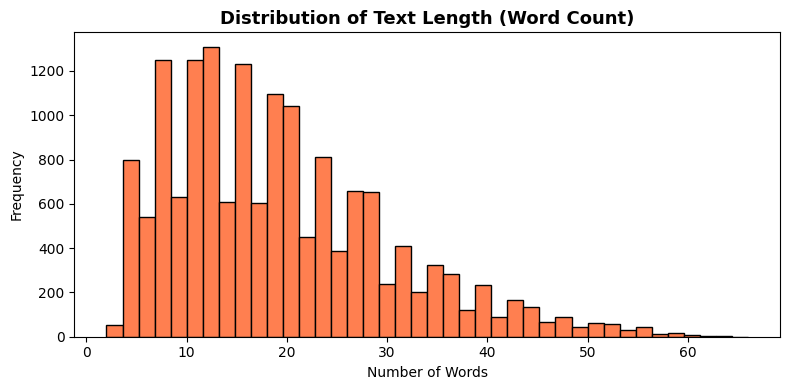

Average text length : 19.2 words
Max text length     : 66 words
Min text length     : 2 words


In [310]:
# --- Text Length Analysis ---
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(df['text_length'], bins=40, color='coral', edgecolor='black')
plt.title('Distribution of Text Length (Word Count)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Average text length : {df['text_length'].mean():.1f} words")
print(f"Max text length     : {df['text_length'].max()} words")
print(f"Min text length     : {df['text_length'].min()} words")

## **Text Cleaning**

In [311]:
# 1- Lower Casing
df['text'] = df['text'].apply(lambda x: x.lower())

In [312]:
# 2- Remove Punctuations
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))


In [313]:
df['text'] = df['text'].apply(remove_punctuation)

In [314]:
# 3- Remove Numbers

def remove_numbers(text):
  new = ""
  for i in text:
    if not i.isdigit():
      new = new + i
  return new

df['text'] = df['text'].apply(remove_numbers)

In [315]:
# 4- Remove Urls/ Links

import re
def remove_urls(text):
    # Removes http, https, www links
    return re.sub(r'http\S+|www\.\S+', '', text)

df['text'] = df['text'].apply(remove_urls)
print("✅ URLs removed!")

✅ URLs removed!


In [316]:
# 5- Remove HTML Tags

def remove_html_tags(text):
    # Removes tags like <br>, <p>, <b> etc.
    return re.sub(r'<.*?>', '', text)

df['text'] = df['text'].apply(remove_html_tags)
print("✅ HTML tags removed!")

✅ HTML tags removed!


In [317]:
# 6- Remove Emojis & Special Characters

def remove_emojis(text):
  new = ""
  for i in text:
    if i.isascii():
      new = new + i
  return new

df['text'] = df['text'].apply(remove_emojis)

In [318]:
# 7- Remove Stopwords

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [319]:
stop_words = set(stopwords.words('english'))

In [320]:
def remove(txt):
  words = word_tokenize(txt)
  cleaned = []
  for i in words:
    if not i in stop_words:
      cleaned.append(i)
  return " ".join(cleaned)

In [321]:
df['text'] = df['text'].apply(remove)

In [322]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [323]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized)

df['text'] = df['text'].apply(lemmatize_text)

# Preview result
print("Sample after lemmatization:")
print(df['text'].iloc[1])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Sample after lemmatization:
go feeling hopeless damned hopeful around someone care awake


## **Bag of Word Explain and Example**

In [324]:
# Bag of Word

from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "I love pizza",
    "Pizza is the best",
    "I love pasta",
    "Pasta is great"
]

vectorizer  = CountVectorizer()

#vectorizer = CountVectorizer(ngram_range=(3,3))  # using N grams


X = vectorizer.fit_transform(documents)

print("Vocabulary :",vectorizer.get_feature_names_out())
print("\nBoW Matrix : \n",X.toarray())

Vocabulary : ['best' 'great' 'is' 'love' 'pasta' 'pizza' 'the']

BoW Matrix : 
 [[0 0 0 1 0 1 0]
 [1 0 1 0 0 1 1]
 [0 0 0 1 1 0 0]
 [0 1 1 0 1 0 0]]


## **TFIDF Example**

In [325]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "I love pizza",
    "Pizza is the best",
    "I love pasta",
    "Pasta is great"
]

vectorizer  = TfidfVectorizer()


X = vectorizer.fit_transform(documents)

print("Vocabulary :",vectorizer.get_feature_names_out())
print("\nBoW Matrix : \n",X.toarray())

Vocabulary : ['best' 'great' 'is' 'love' 'pasta' 'pizza' 'the']

BoW Matrix : 
 [[0.         0.         0.         0.70710678 0.         0.70710678
  0.        ]
 [0.55528266 0.         0.43779123 0.         0.         0.43779123
  0.55528266]
 [0.         0.         0.         0.70710678 0.70710678 0.
  0.        ]
 [0.         0.66767854 0.52640543 0.         0.52640543 0.
  0.        ]]


## **Back to project**

In [326]:
df.head()

,text,emotion,text_length
0,didnt feel humiliated,4,4
1,go feeling hopeless damned hopeful around some...,4,21
2,im grabbing minute post feel greedy wrong,0,10
3,ever feeling nostalgic fireplace know still pr...,3,18
4,feeling grouchy,0,4


In [327]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.2, random_state=42,stratify=df['emotion'])

In [328]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [329]:
# Bag of Word
BoW = CountVectorizer()
X_train_BoW = BoW.fit_transform(X_train)
X_test_BoW = BoW.transform(X_test)

In [330]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB()
nb_model.fit(X_train_BoW, y_train)

MultinomialNB()

In [331]:
y_pred_Bow = nb_model.predict(X_test_BoW)

In [332]:
accuracy_score(y_test, y_pred_Bow)

0.7871875

In [333]:
# TFIDF
TFIDF = TfidfVectorizer()

X_train_TFIDF = TFIDF.fit_transform(X_train)
X_test_TFIDF = TFIDF.transform(X_test)

In [334]:
nb2_model = MultinomialNB()
nb2_model.fit(X_train_TFIDF, y_train)

MultinomialNB()

In [335]:
y_pred_TFIDF = nb2_model.predict(X_test_TFIDF)

In [336]:
accuracy_score(y_test, y_pred_TFIDF)

0.6778125

In [337]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter= 1000)
lr_model.fit(X_train_TFIDF, y_train)

LogisticRegression(max_iter=1000)

In [338]:
log_pred = lr_model.predict(X_test_TFIDF)

In [339]:
accuracy_score(y_test, log_pred)

0.8625

In [340]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train_TFIDF, y_train)

SVC()

In [341]:
svm_pred = svm_model.predict(X_test_TFIDF)

In [342]:
accuracy_score(y_test, svm_pred)

0.8546875

In [343]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train_TFIDF, y_train)

RandomForestClassifier()

In [344]:
rf_pred = rf_model.predict(X_test_TFIDF)

In [345]:
accuracy_score(y_test, rf_pred)

0.875625

In [346]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()
xgb_model.fit(X_train_TFIDF, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [347]:
xgb_pred = xgb_model.predict(X_test_TFIDF)

In [348]:
accuracy_score(y_test, xgb_pred)

0.8828125

In [349]:
xgb_model_Bow = XGBClassifier()
xgb_model_Bow.fit(X_train_BoW, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [350]:
xgb_pred_Bow = xgb_model_Bow.predict(X_test_BoW)

In [351]:
accuracy_score(y_test, xgb_pred_Bow)

0.880625

In [367]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_TFIDF, y_train)

GradientBoostingClassifier()

In [368]:
y_pred_gb = gb_model.predict(X_test_TFIDF)

In [369]:
accuracy_score(y_test, y_pred_gb)

0.8421875

In [363]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_TFIDF, y_train)

LinearSVC()

In [364]:
y_pred_lin = model.predict(X_test_TFIDF)

In [365]:
accuracy_score(y_test, y_pred_lin)

0.890625

In [366]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lin))


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       432
           1       0.87      0.88      0.87       387
           2       0.89      0.92      0.91      1072
           3       0.79      0.76      0.77       261
           4       0.93      0.93      0.93       933
           5       0.87      0.74      0.80       115

    accuracy                           0.89      3200
   macro avg       0.87      0.85      0.86      3200
weighted avg       0.89      0.89      0.89      3200



In [370]:
from sklearn.metrics import classification_report

emotion_names = le.classes_.tolist()  # actual emotion name labels

models_predictions = {
    "Naive Bayes (BoW)"        : y_pred_Bow,
    "Naive Bayes (TF-IDF)"     : y_pred_TFIDF,
    "Logistic Regression"      : log_pred,
    "SVM (RBF)"                : svm_pred,
    "Random Forest"            : rf_pred,
    "XGBoost (TF-IDF)"         : xgb_pred,
    "XGBoost (BoW)"            : xgb_pred_Bow,
    "Gradient Boosting"        : y_pred_gb,
    "LinearSVC"                : y_pred_lin,
}

for model_name, preds in models_predictions.items():
    print(f"\n{'='*55}")
    print(f"  📋 {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_test, preds, target_names=emotion_names))


  📋 Naive Bayes (BoW)
              precision    recall  f1-score   support

       anger       0.87      0.68      0.76       432
        fear       0.85      0.65      0.74       387
         joy       0.76      0.94      0.84      1072
        love       0.89      0.31      0.46       261
     sadness       0.77      0.94      0.84       933
    surprise       0.88      0.12      0.21       115

    accuracy                           0.79      3200
   macro avg       0.84      0.61      0.64      3200
weighted avg       0.80      0.79      0.76      3200


  📋 Naive Bayes (TF-IDF)
              precision    recall  f1-score   support

       anger       0.95      0.31      0.47       432
        fear       0.93      0.29      0.44       387
         joy       0.62      0.98      0.76      1072
        love       1.00      0.07      0.14       261
     sadness       0.69      0.92      0.79       933
    surprise       0.00      0.00      0.00       115

    accuracy                

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [371]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# We use Pipeline so vectorizer + model are tested together properly
cv_models = {
    "LinearSVC"           : Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC())]),
    "Logistic Regression" : Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=1000))]),
    "XGBoost"             : Pipeline([("tfidf", TfidfVectorizer()), ("clf", XGBClassifier(verbosity=0))]),
}

print("📊 Cross Validation Results (5-Fold)\n")
print(f"{'Model':<25} {'Mean Accuracy':>15} {'Std Dev':>10}")
print("-" * 52)

for name, pipeline in cv_models.items():
    scores = cross_val_score(pipeline, df['text'], df['emotion'], cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():.4f}         ±{scores.std():.4f}")

📊 Cross Validation Results (5-Fold)

Model                       Mean Accuracy    Std Dev
----------------------------------------------------
LinearSVC                 0.8887         ±0.0089
Logistic Regression       0.8569         ±0.0069
XGBoost                   0.8815         ±0.0074


In [372]:
from sklearn.metrics import accuracy_score

# Collect all results in one place
results = {
    "Naive Bayes (BoW)"        : accuracy_score(y_test, y_pred_Bow),
    "Naive Bayes (TF-IDF)"     : accuracy_score(y_test, y_pred_TFIDF),
    "Logistic Regression"      : accuracy_score(y_test, log_pred),
    "SVM (RBF)"                : accuracy_score(y_test, svm_pred),
    "Random Forest"            : accuracy_score(y_test, rf_pred),
    "XGBoost (TF-IDF)"         : accuracy_score(y_test, xgb_pred),
    "XGBoost (BoW)"            : accuracy_score(y_test, xgb_pred_Bow),
    "Gradient Boosting"        : accuracy_score(y_test, y_pred_gb),
    "LinearSVC"                : accuracy_score(y_test, y_pred_lin),
}

# Sort best to worst
results_sorted = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

# Print as a clean table
print(f"{'Rank':<6} {'Model':<25} {'Accuracy':>10}")
print("-" * 44)
for rank, (name, acc) in enumerate(results_sorted.items(), 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"  {rank}."
    print(f"{medal:<6} {name:<25} {acc:.4f}")

Rank   Model                       Accuracy
--------------------------------------------
🥇      LinearSVC                 0.8906
🥈      XGBoost (TF-IDF)          0.8828
🥉      XGBoost (BoW)             0.8806
  4.   Random Forest             0.8756
  5.   Logistic Regression       0.8625
  6.   SVM (RBF)                 0.8547
  7.   Gradient Boosting         0.8422
  8.   Naive Bayes (BoW)         0.7872
  9.   Naive Bayes (TF-IDF)      0.6778


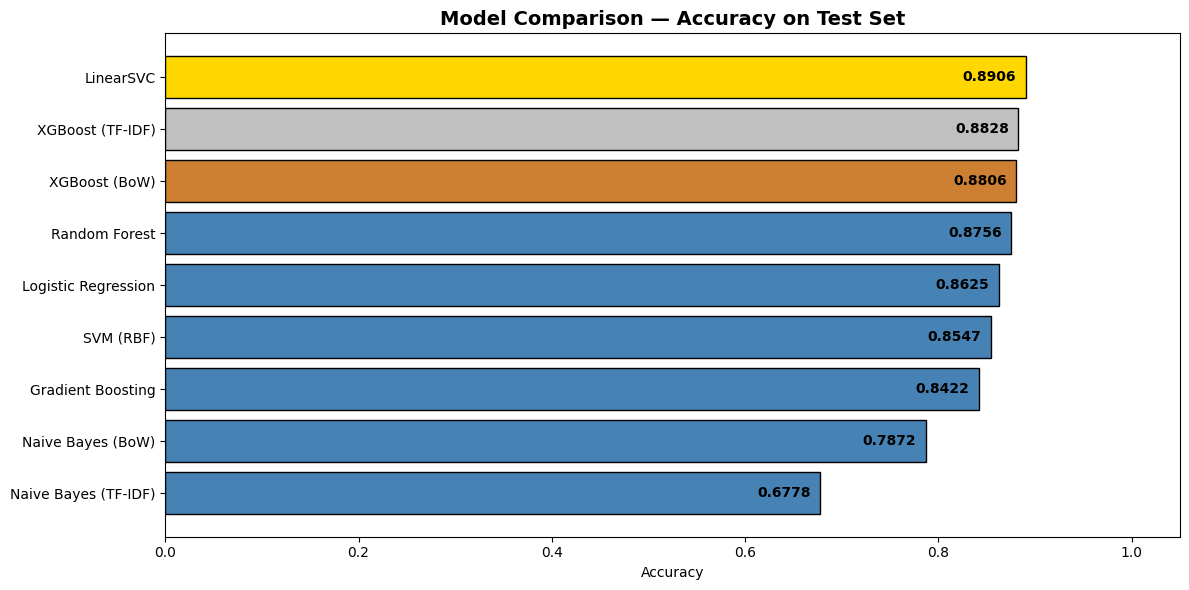

In [373]:
# --- Bar Chart Comparison ---
names   = list(results_sorted.keys())
accs    = list(results_sorted.values())
colors  = ['gold', 'silver', '#cd7f32'] + ['steelblue'] * (len(names) - 3)  # gold, silver, bronze

plt.figure(figsize=(12, 6))
bars = plt.barh(names[::-1], accs[::-1], color=colors[::-1], edgecolor='black')

# Show accuracy value on each bar
for bar, acc in zip(bars, accs[::-1]):
    plt.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', ha='right', fontsize=10, color='black', fontweight='bold')

plt.title('Model Comparison — Accuracy on Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

## **Save the Models**

In [ ]:
import joblib

In [ ]:
# Save TF-IDF Vectorizer
joblib.dump(TFIDF, 'saved_models/tfidf_vectorizer.joblib')
print('✅ TF-IDF Vectorizer saved  →  saved_models/tfidf_vectorizer.joblib')

# Save Label Encoder (to convert numbers back to emotion names)
joblib.dump(le, 'saved_models/label_encoder.joblib')
print('✅ Label Encoder saved      →  saved_models/label_encoder.joblib')

In [ ]:
# -----------------------------------------------
# 🥇 1st — LinearSVC  (best for sparse text data)
# -----------------------------------------------
joblib.dump(model, 'saved_models/linearsvc_model.joblib')
print('🥇 LinearSVC saved          →  saved_models/linearsvc_model.joblib')

# -----------------------------------------------
# 🥈 2nd — Logistic Regression
# -----------------------------------------------
joblib.dump(lr_model, 'saved_models/logistic_regression_model.joblib')
print('🥈 Logistic Regression saved →  saved_models/logistic_regression_model.joblib')

# -----------------------------------------------
# 🥉 3rd — XGBoost (TF-IDF version)
# -----------------------------------------------
joblib.dump(xgb_model, 'saved_models/xgboost_model.joblib')
print('🥉 XGBoost saved            →  saved_models/xgboost_model.joblib')

print('\n🎉 All 3 models saved successfully in saved_models/ folder!')